# Convolutional Neural Networks (CNNs) for Image Classification

This notebook explores the application of Convolutional Neural Networks (CNNs) for image classification tasks using TensorFlow and Keras. It demonstrates several key concepts and datasets:

1.  **MNIST Digit Classification:**
    *   Loads and preprocesses the MNIST dataset (handwritten digits).
    *   Builds, compiles, trains, and evaluates a basic CNN model.
    *   Visualizes training and validation accuracy and loss over epochs.

2.  **CIFAR-10 Image Classification with Data Augmentation:**
    *   Loads and preprocesses the CIFAR-10 dataset (10 classes of color images).
    *   Implements data augmentation (rotation, shifting, flipping, zooming) using `ImageDataGenerator`.
    *   Compares the performance of a CNN model trained with and without data augmentation, highlighting the benefits of augmentation in preventing overfitting and improving generalization.

3.  **Fashion MNIST Feature Map Visualization:**
    *   Loads and preprocesses the Fashion MNIST dataset.
    *   Builds and trains a CNN model.
    *   Includes custom functions to extract and visualize feature maps from the convolutional layers, providing insight into what the network learns at different stages.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [ ]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Preprocess the dataset: Normalize the pixel values to [0, 1] and reshape the input
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1)).astype('float32') / 255


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# One-hot encode the labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

In [ ]:
import matplotlib.pyplot as plt

# Display a few sample images from the training set
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {tf.argmax(train_labels[i])}") # Use tf.argmax for one-hot encoded labels
    plt.axis('off')
plt.suptitle('Sample MNIST Training Images')
plt.show()

In [ ]:
# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels),
                    batch_size=64)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8902 - loss: 0.3684 - val_accuracy: 0.9855 - val_loss: 0.0462
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9836 - loss: 0.0519 - val_accuracy: 0.9880 - val_loss: 0.0364
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9895 - val_loss: 0.0351
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9921 - loss: 0.0250 - val_accuracy: 0.9878 - val_loss: 0.0339
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.9916 - val_loss: 0.0275
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.9954 - loss: 0.0133 - val_accuracy: 0.9903 - val_loss: 0.0302
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9962 - loss: 0.0115 - val_accuracy: 0.9899 - val_loss: 0.0320
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9971 - loss: 0.0079 - 

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9877 - loss: 0.0423


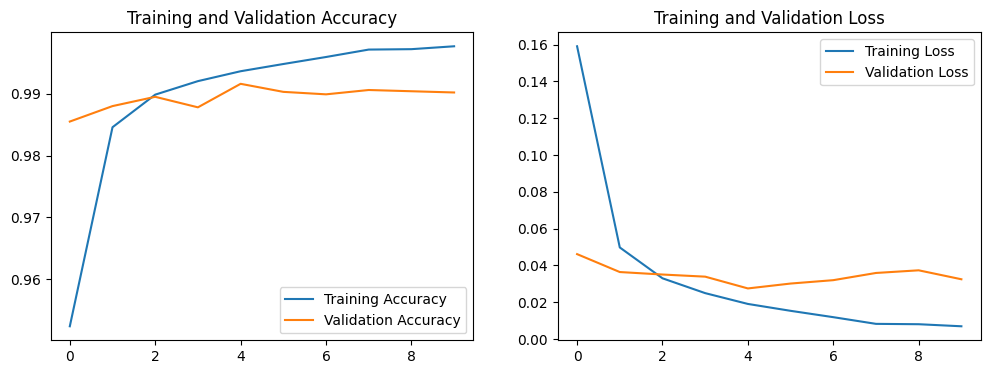

Test accuracy: 0.9901999831199646


In [ ]:
# Plot training and validation accuracy and loss over epochs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

print(f"Test accuracy: {test_acc}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [ ]:
# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Preprocess the dataset: Normalize pixel values to [0, 1]
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [ ]:
# One-hot encode the labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

In [ ]:
# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model on the augmented data
train_datagen = datagen.flow(train_images, train_labels, batch_size=64)

history_augmented = model.fit(train_datagen, epochs=10,
                              validation_data=(test_images, test_labels))

# Evaluate the model on the test set with augmented training
test_loss_augmented, test_acc_augmented = model.evaluate(test_images, test_labels)

# Train the model on the original (non-augmented) data
model_original = models.clone_model(model)  # Create a copy of the model
model_original.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_original = model_original.fit(train_images, train_labels, epochs=10,
                                      validation_data=(test_images, test_labels))

# Evaluate the model on the test set without augmentation
test_loss_original, test_acc_original = model_original.evaluate(test_images, test_labels)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 127ms/step - accuracy: 0.3075 - loss: 1.8590 - val_accuracy: 0.4952 - val_loss: 1.3899
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 127ms/step - accuracy: 0.5022 - loss: 1.3813 - val_accuracy: 0.5730 - val_loss: 1.2109
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - accuracy: 0.5637 - loss: 1.2297 - val_accuracy: 0.6002 - val_loss: 1.1310
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.5989 - loss: 1.1308 - val_accuracy: 0.6177 - val_loss: 1.1050
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.6271 - loss: 1.0608 - val_accuracy: 0.6601 - val_loss: 0.9518
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 131ms/step - accuracy: 0.6476 - loss: 1.0052 - val_accuracy: 0.6922 - val_loss: 0.8864
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 126ms/step - accuracy: 0.6622 - loss: 0.9648 - val_accuracy: 0.6828 - val_loss: 0.9049
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.6722 - loss: 0.9328 

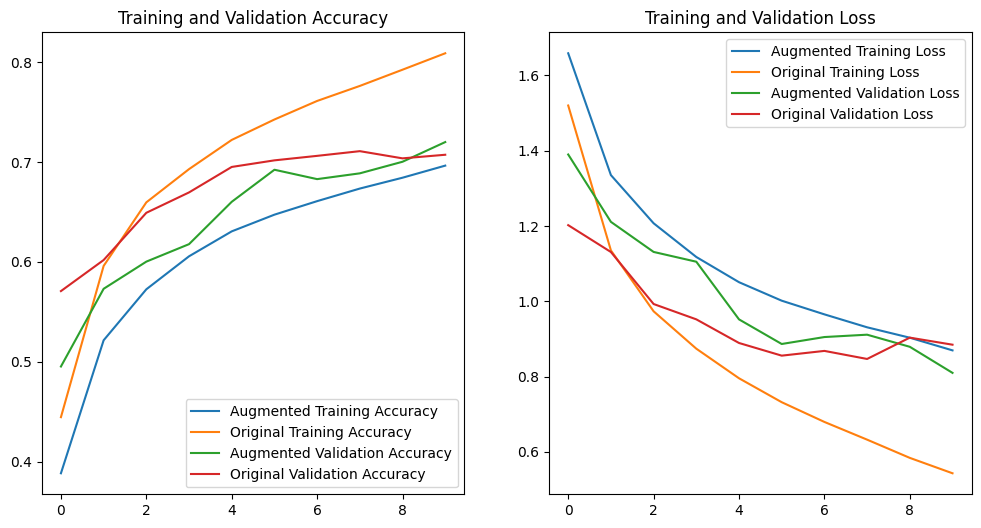

Test accuracy without augmentation: 0.7071999907493591
Test accuracy with augmentation: 0.7199000120162964


In [ ]:
# Plot training accuracy and loss for augmented and original training
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_augmented.history['accuracy'], label='Augmented Training Accuracy')
plt.plot(history_original.history['accuracy'], label='Original Training Accuracy')
plt.plot(history_augmented.history['val_accuracy'], label='Augmented Validation Accuracy')
plt.plot(history_original.history['val_accuracy'], label='Original Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_augmented.history['loss'], label='Augmented Training Loss')
plt.plot(history_original.history['loss'], label='Original Training Loss')
plt.plot(history_augmented.history['val_loss'], label='Augmented Validation Loss')
plt.plot(history_original.history['val_loss'], label='Original Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

print(f"Test accuracy without augmentation: {test_acc_original}")
print(f"Test accuracy with augmentation: {test_acc_augmented}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.7678 - loss: 0.6542
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.8773 - loss: 0.3446
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.8973 - loss: 0.2889
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 27ms/step - accuracy: 0.9057 - loss: 0.2636
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.9147 - loss: 0.2390
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9204 - loss: 0.2170
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9261 - loss: 0.1993
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.9319 - loss: 0.1866
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9353 - loss: 0.1771
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9398 - loss: 0.1674
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


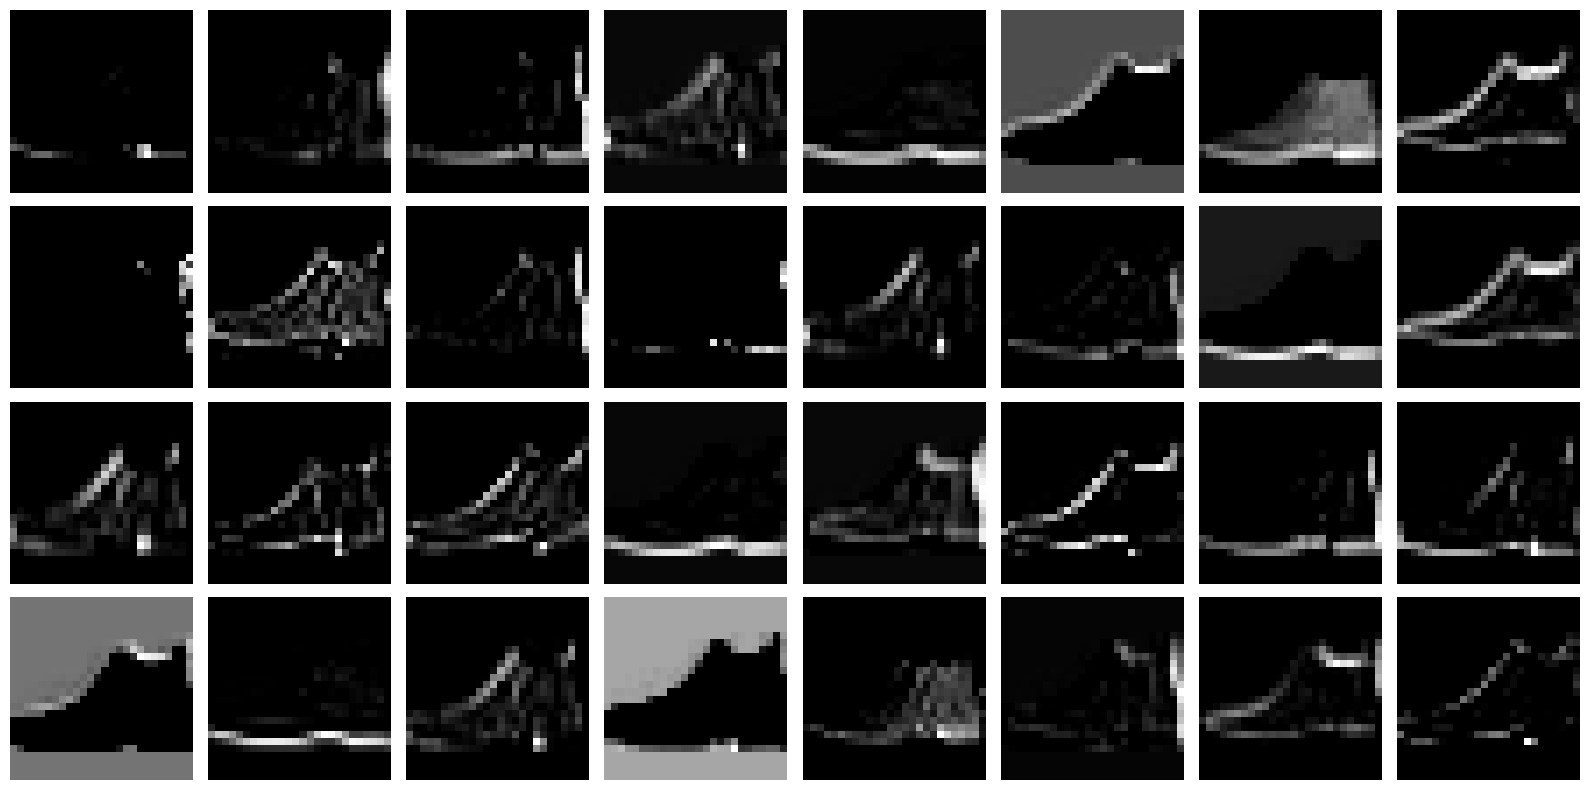

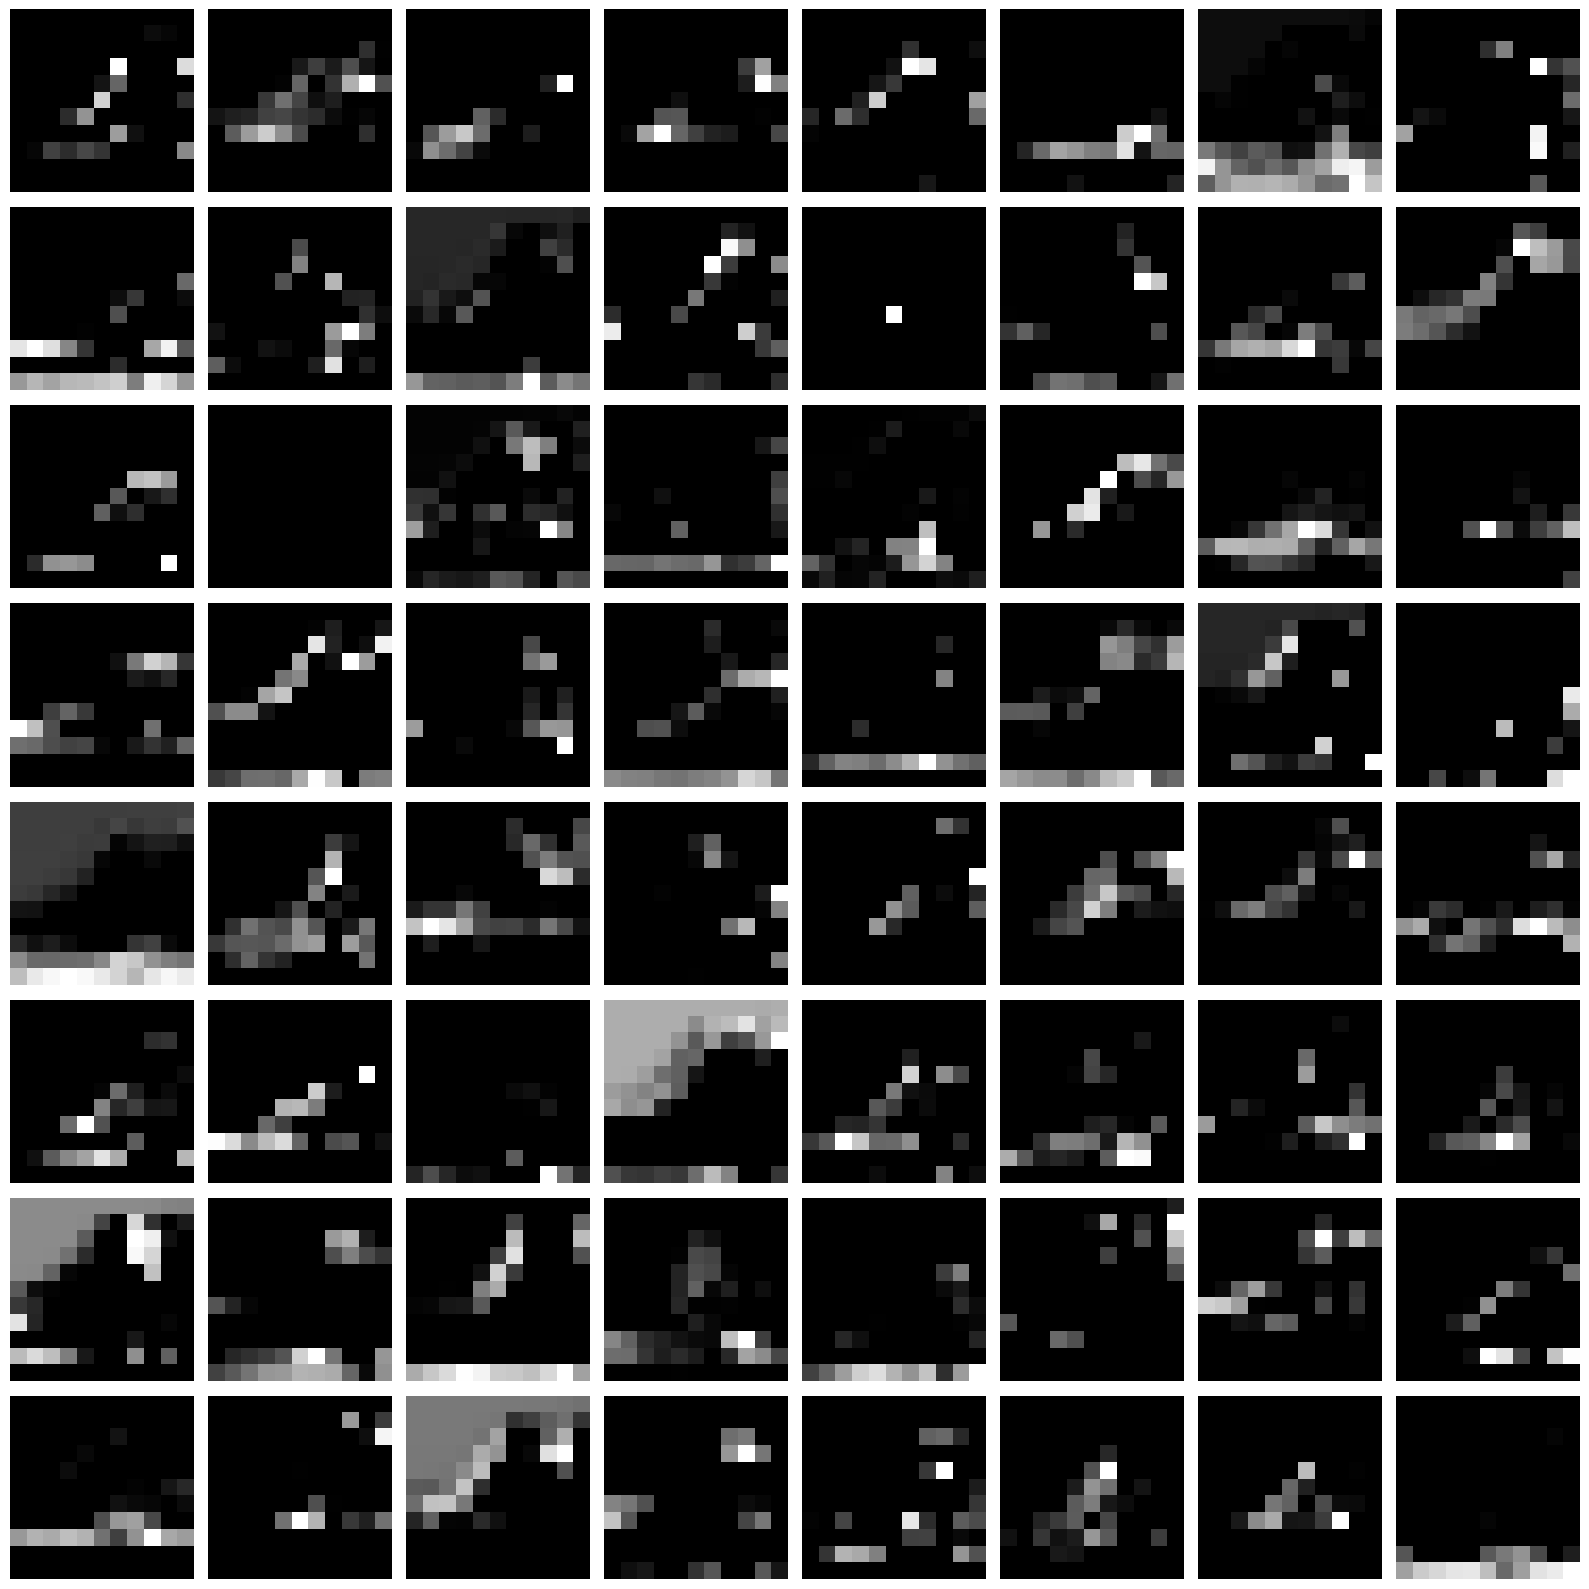

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


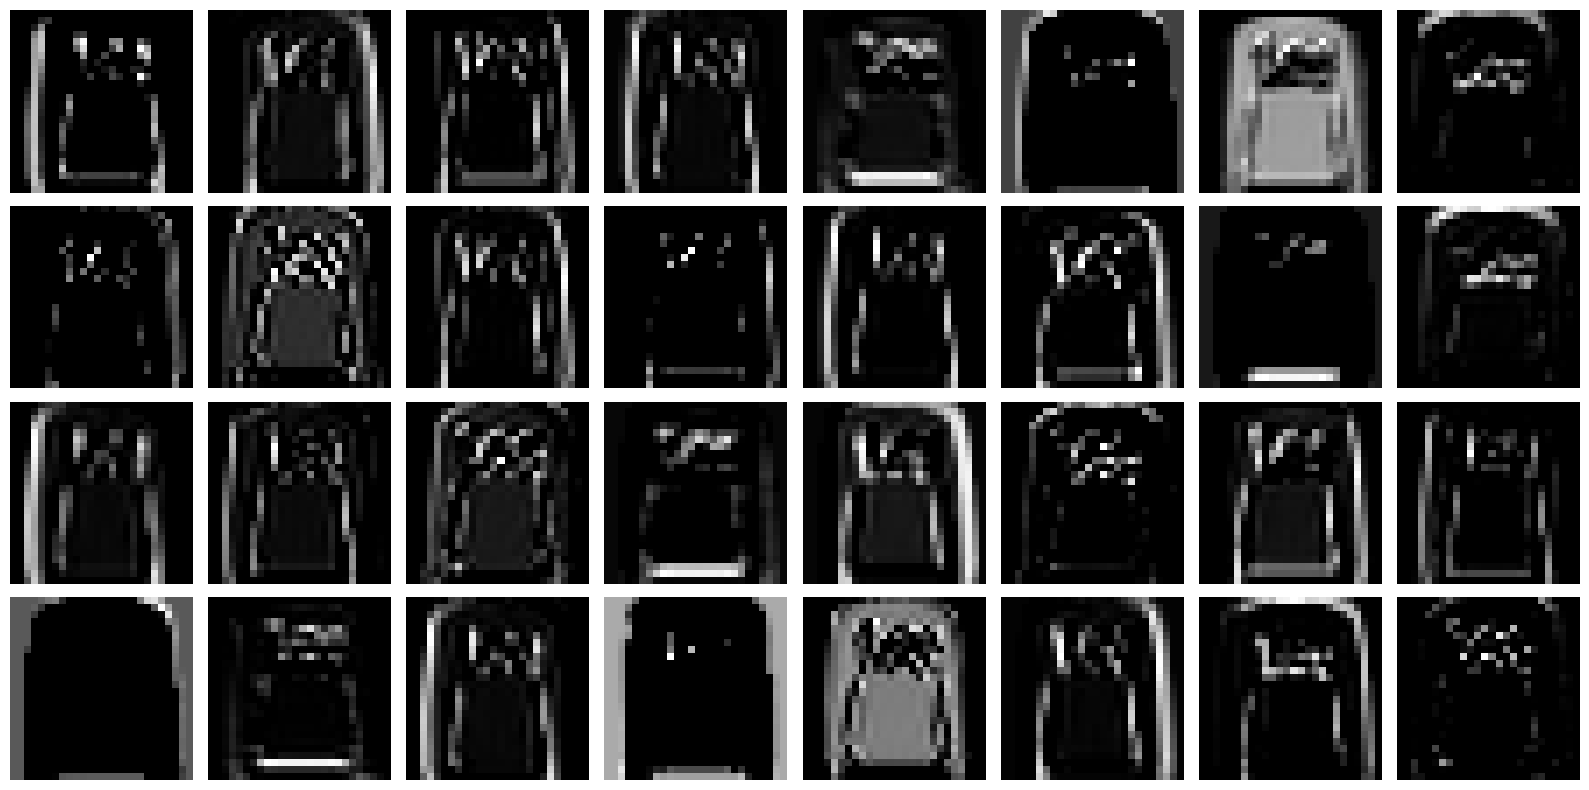

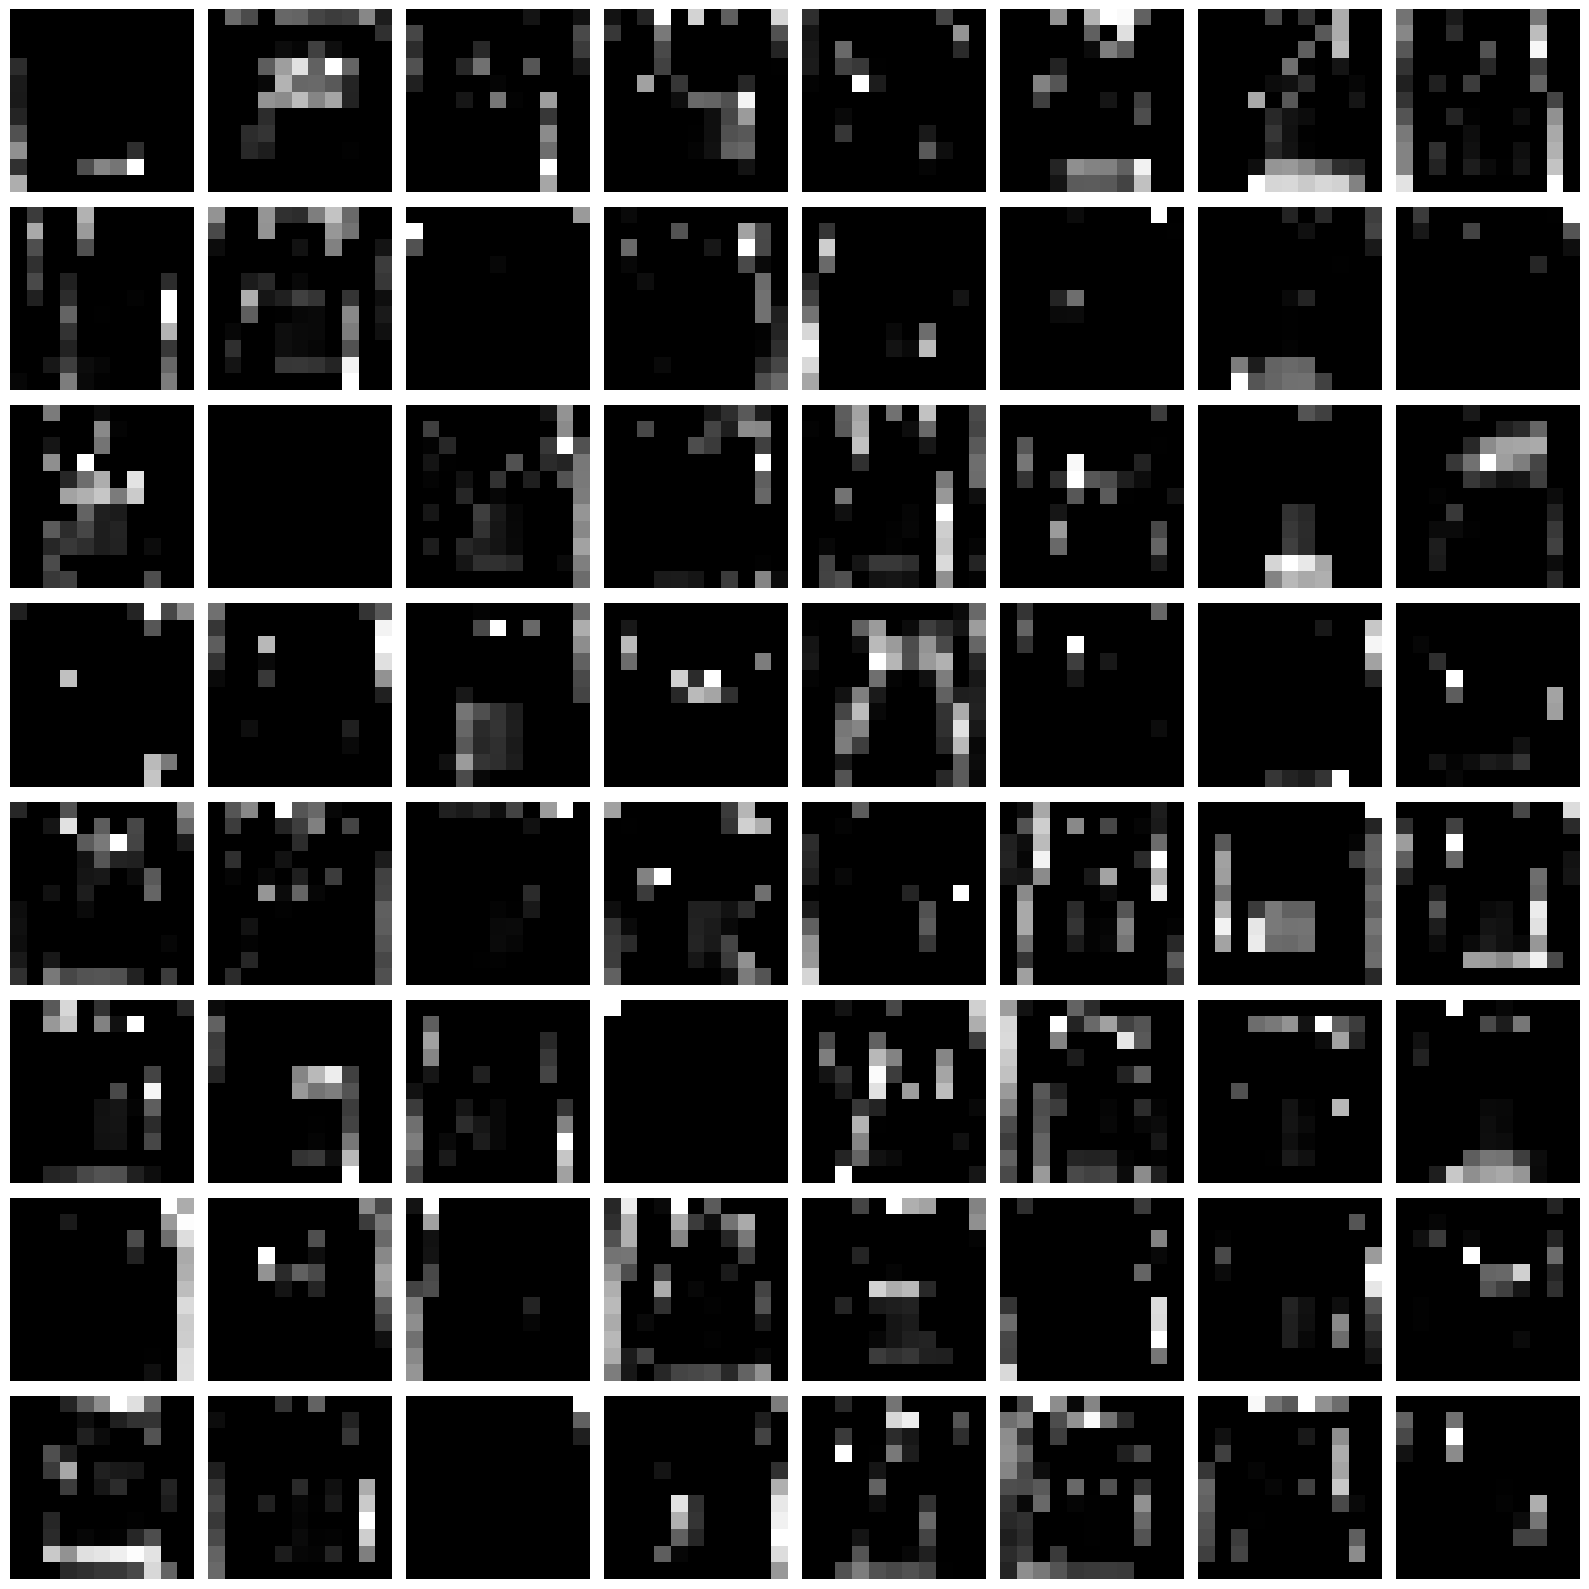

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


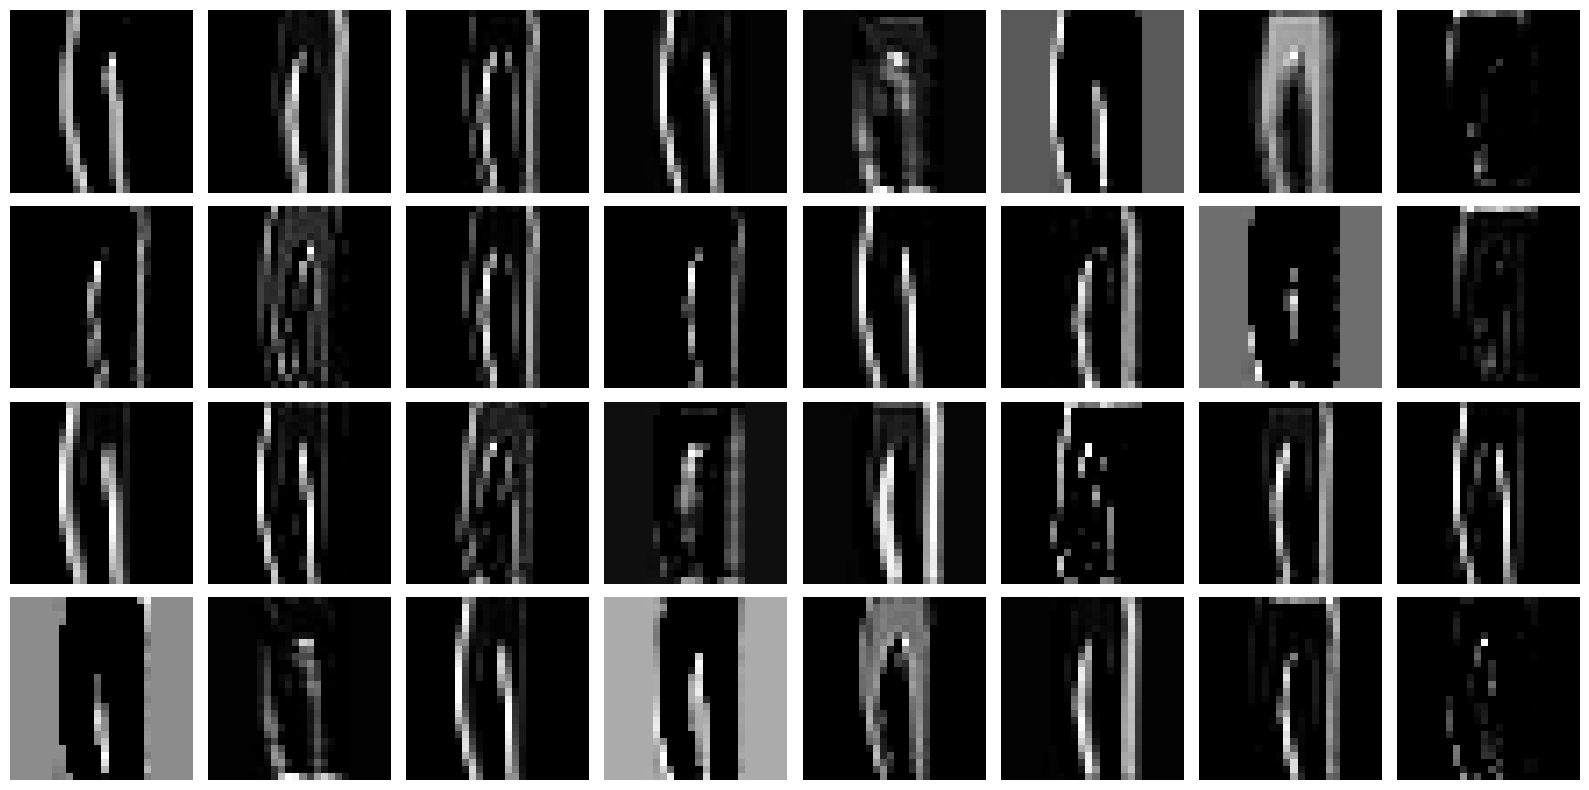

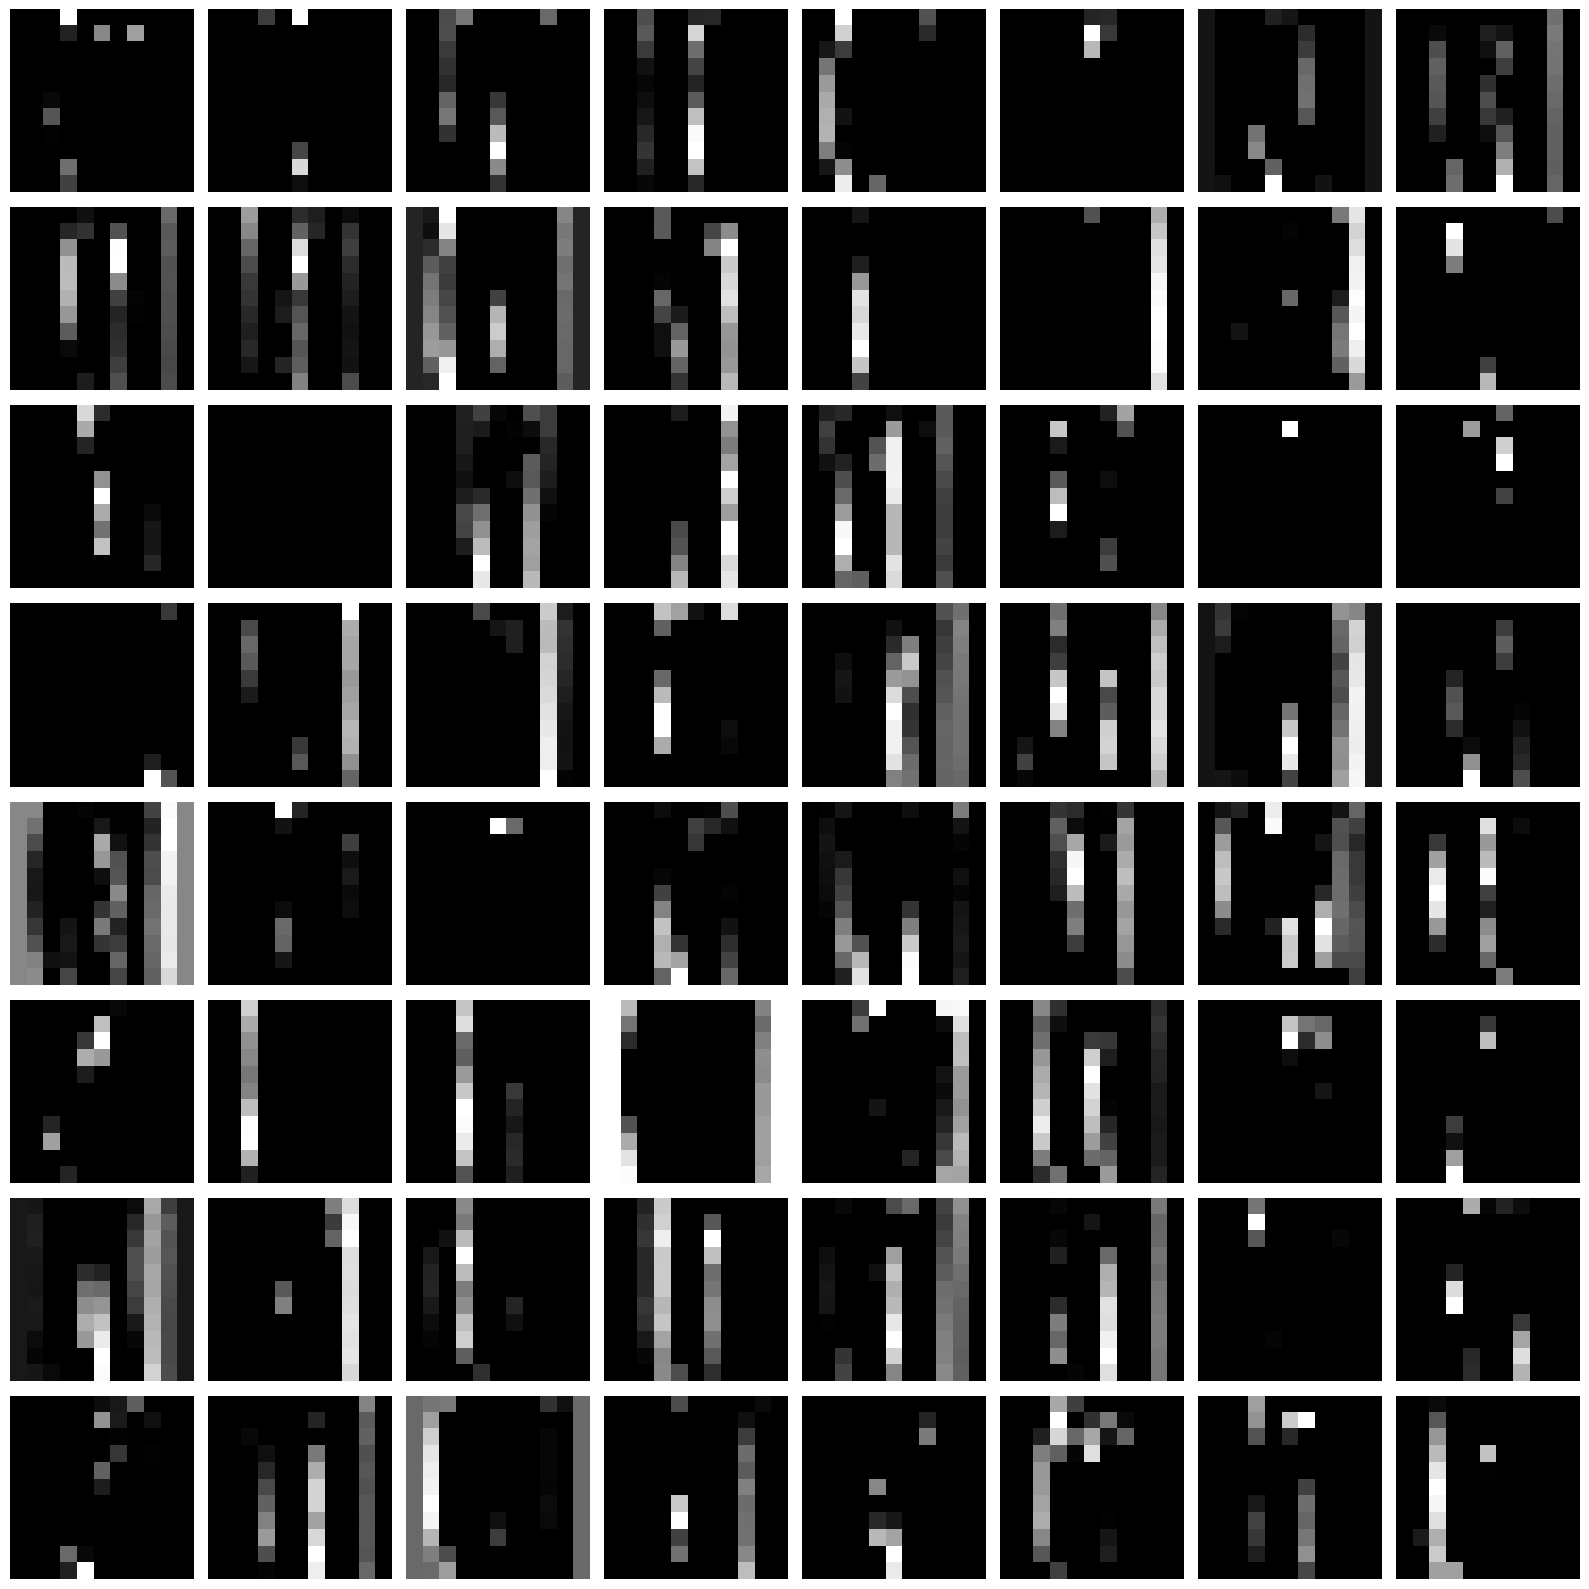

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


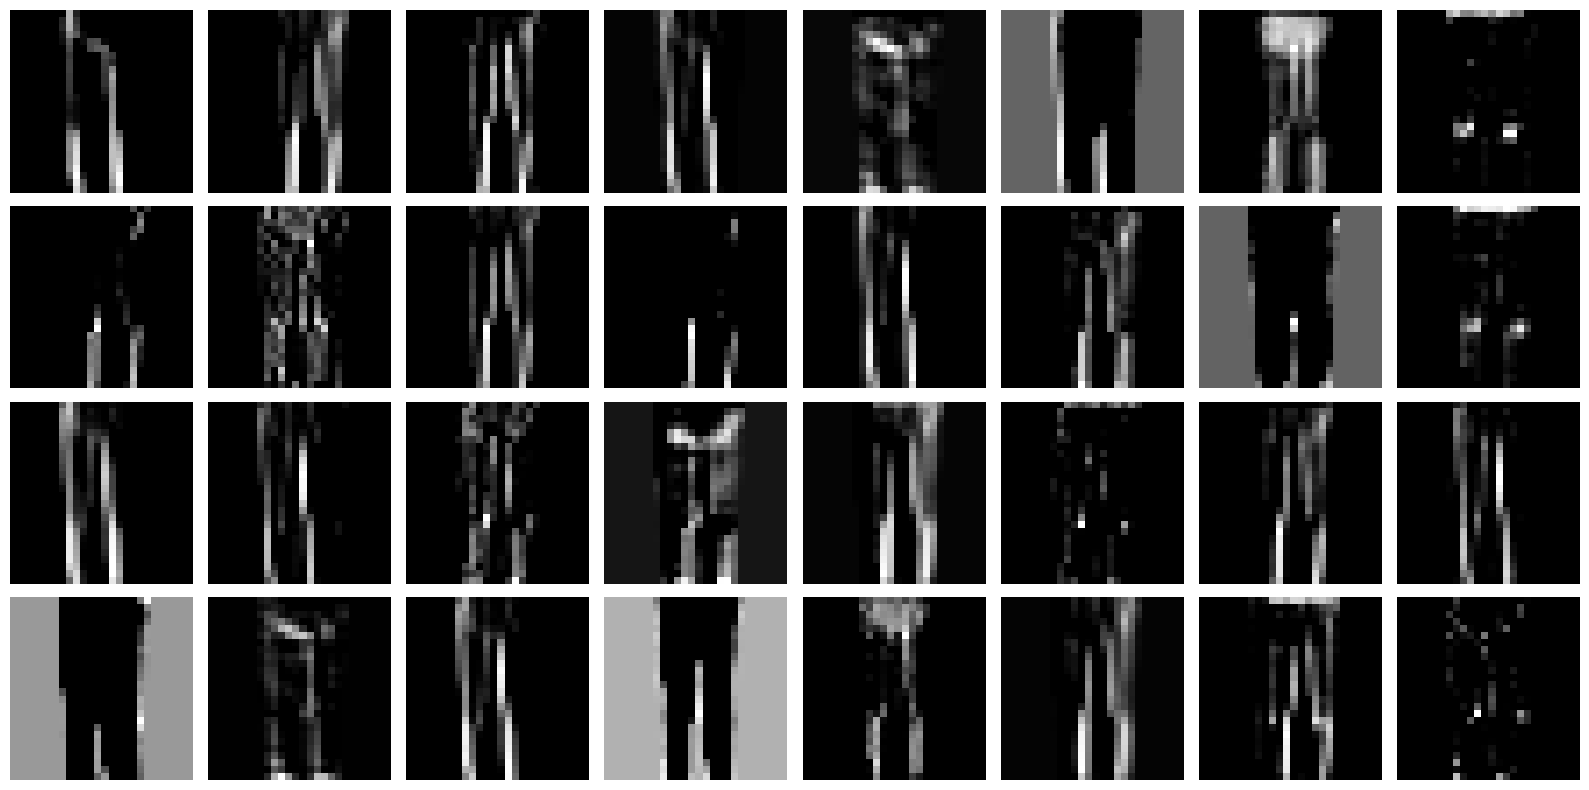

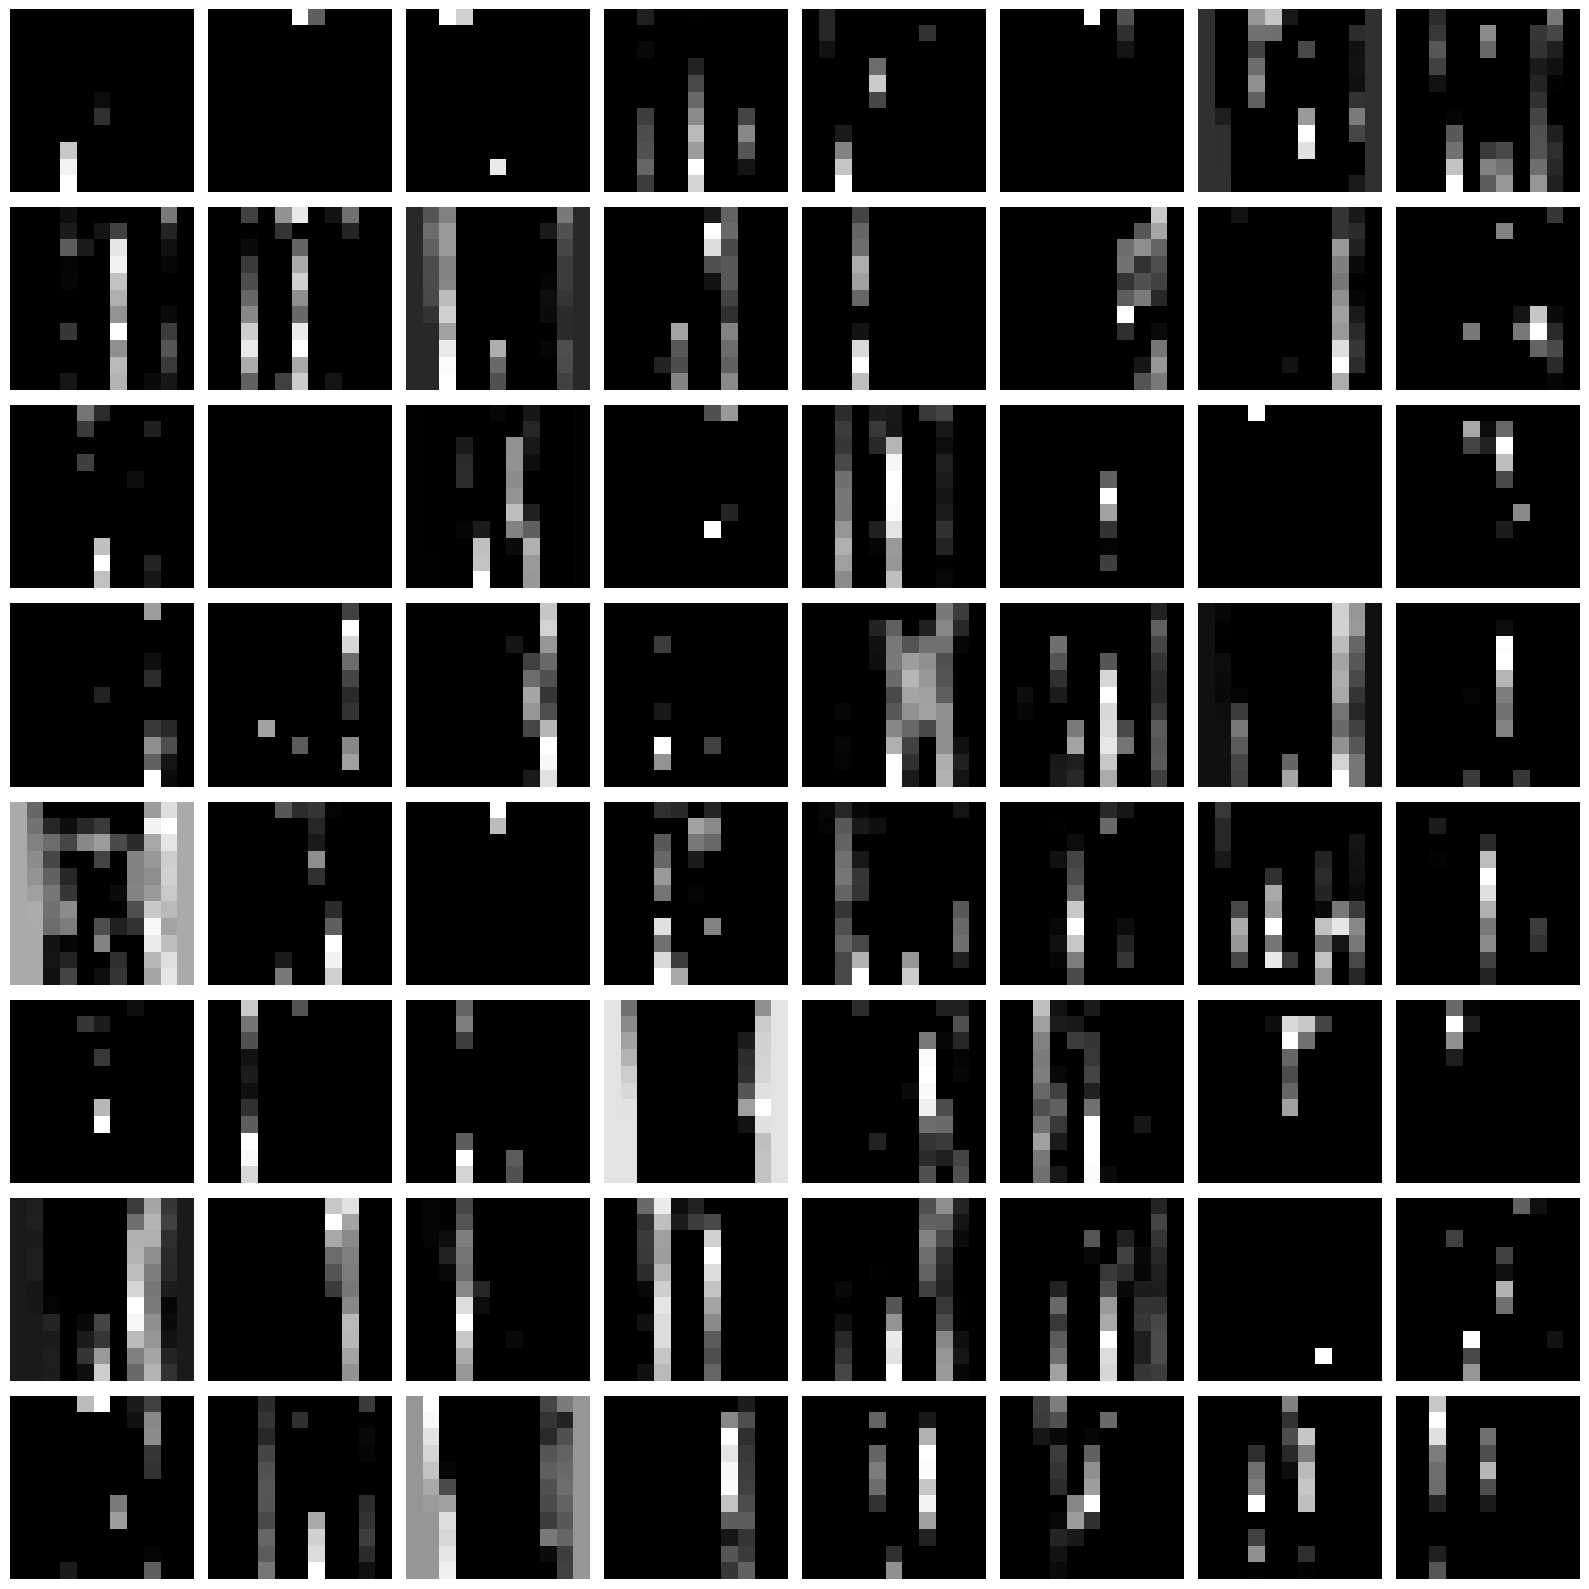

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


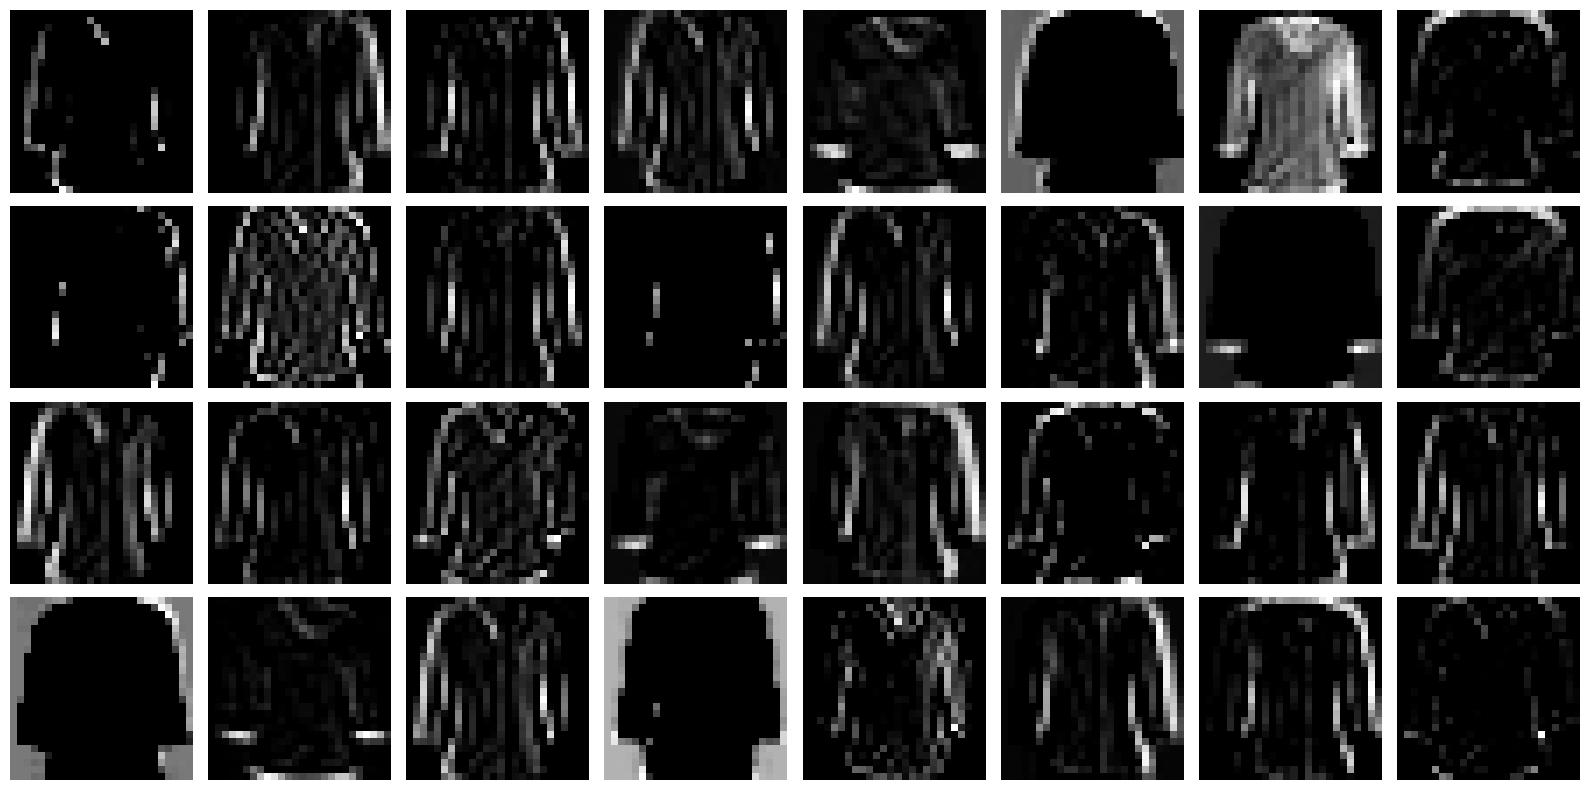

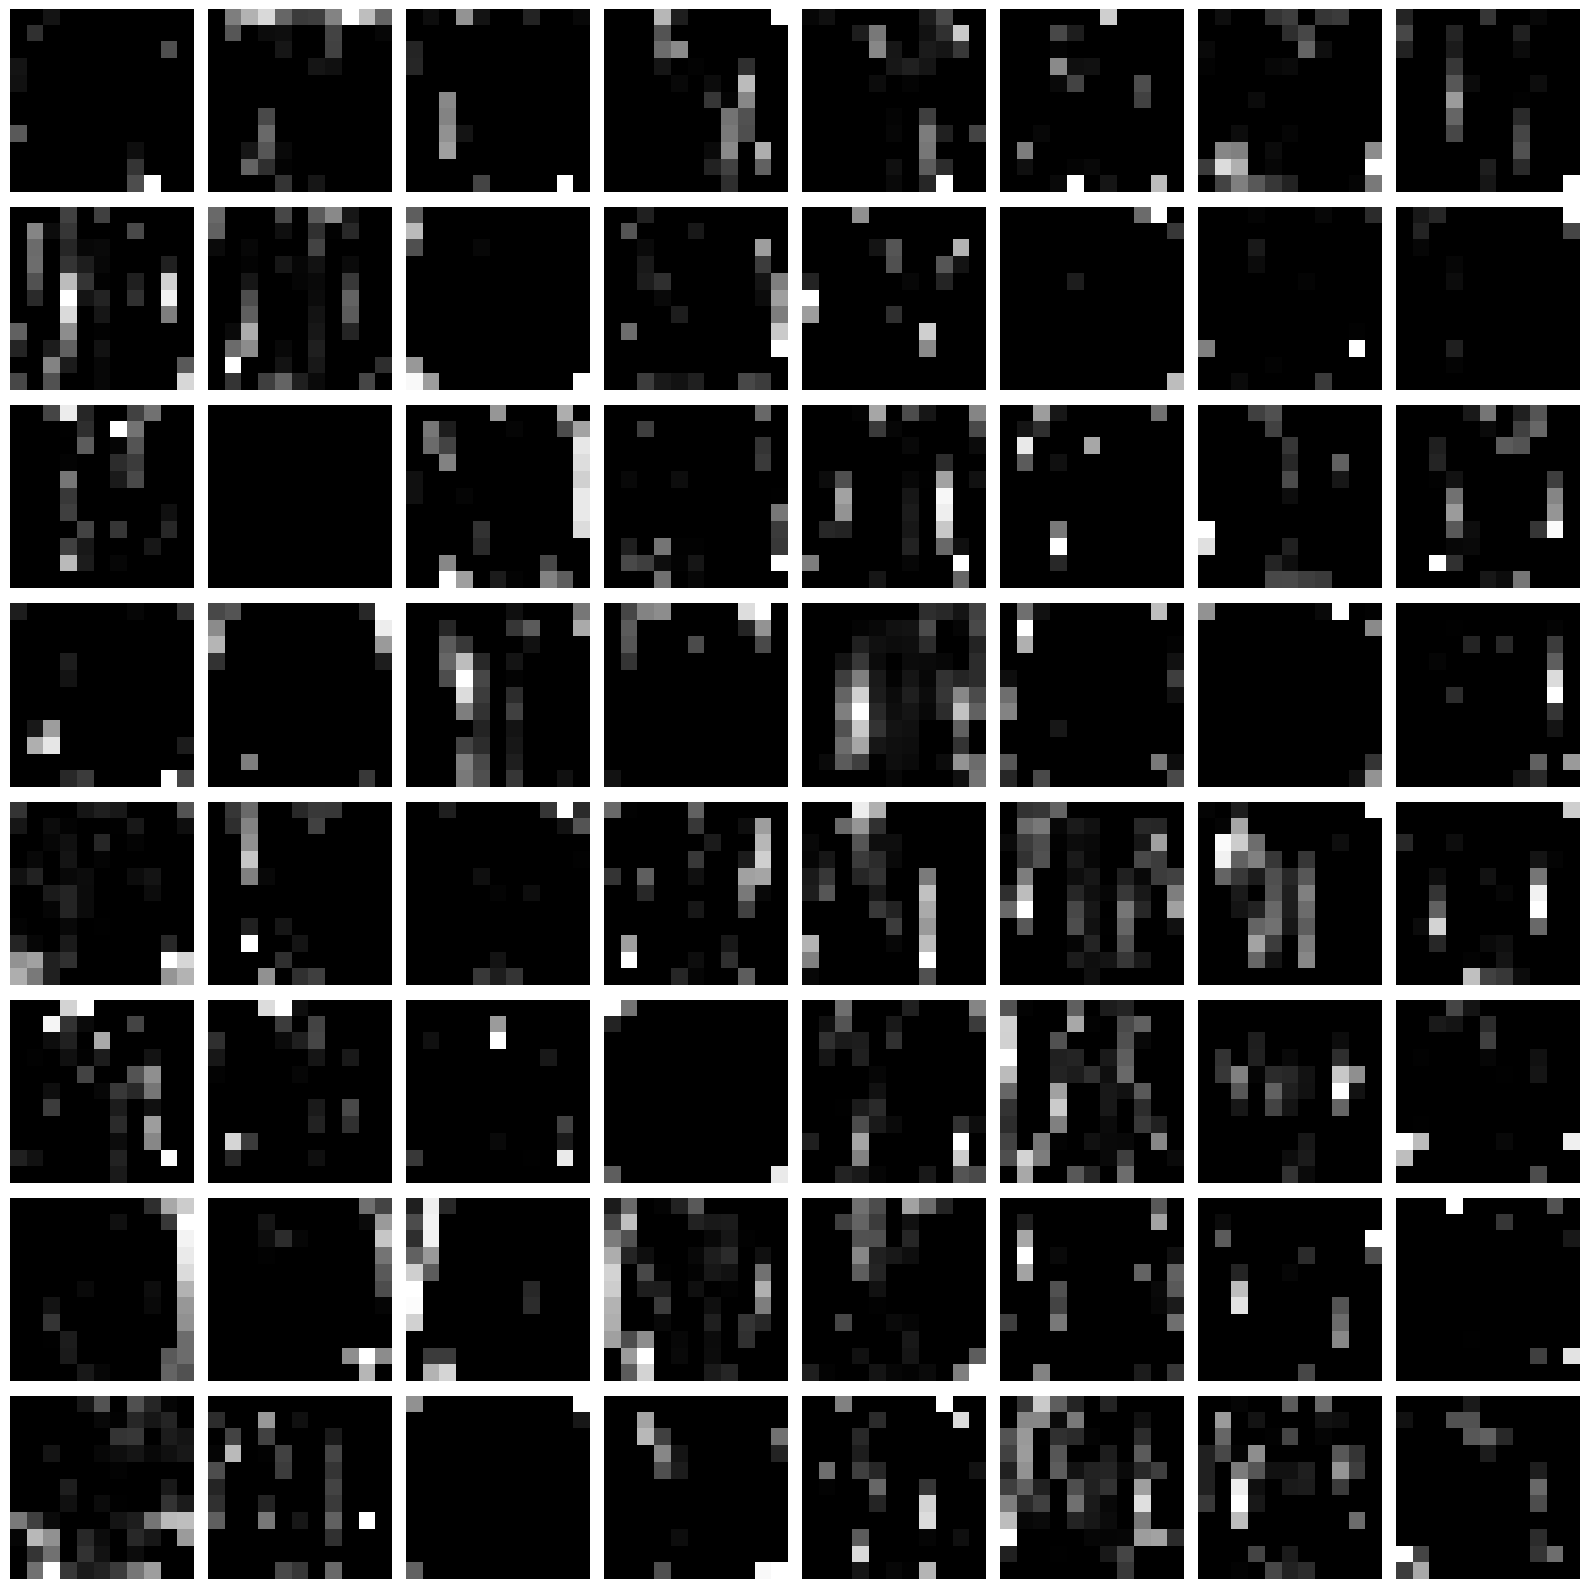

In [ ]:
# Load the Fashion MNIST dataset (as before)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the input to include the channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

import tensorflow as tf

# Define the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10)

# Choose a few input images
sample_images = x_test[:5]  # Select the first 5 test images

# Define a function to extract feature maps
def extract_feature_maps(image):
    """Extracts feature maps from convolutional layers."""
    feature_maps = []
    for layer in model.layers:
        if 'conv2d' in layer.name:
            submodel = tf.keras.models.Model(inputs=model.inputs, outputs=layer.output)
            feature_map = submodel.predict(np.expand_dims(image, axis=0))
            feature_maps.append(feature_map)
    return feature_maps

# Define a function to visualize the feature maps
def visualize_feature_maps(feature_maps):
    """Visualizes the feature maps."""
    for layer_index, feature_map in enumerate(feature_maps):
        num_filters = feature_map.shape[-1]
        num_cols = 8  # Adjust as needed for desired layout
        num_rows = num_filters // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
        for i in range(num_filters):
            row = i // num_cols
            col = i % num_cols
            ax = axes[row, col]
            ax.imshow(feature_map[0, :, :, i], cmap='gray')  # Visualize the i-th filter's output
            ax.axis('off')
        plt.tight_layout()
        plt.show()

# Extract and visualize feature maps for the sample images
for image in sample_images:
    feature_maps = extract_feature_maps(image)
    visualize_feature_maps(feature_maps)